In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv("Unemployment in India.csv")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Remove missing values
df.dropna(inplace=True)

# Display dataset
print(df.head())
print(df.shape)
print(df.columns)

           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019   Monthly                             3.65   
1  Andhra Pradesh   30-06-2019   Monthly                             3.05   
2  Andhra Pradesh   31-07-2019   Monthly                             3.75   
3  Andhra Pradesh   31-08-2019   Monthly                             3.32   
4  Andhra Pradesh   30-09-2019   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  
(740, 7)
Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Emplo

In [3]:
# Independent variables
features = [
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

# Input features
X = df[features]

# Target variable
y = df["Estimated Unemployment Rate (%)"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (592, 2)
Testing data: (148, 2)


In [5]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [6]:
# Predict unemployment rate
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
[ 9.7698  9.05    9.043   5.716   2.3563  7.1355  5.4085 26.1015  9.3944
  8.7068]


In [7]:
# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# R2 Score
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("Mean Absolute Error:", round(mae, 2))
print("Mean Squared Error:", round(mse, 2))
print("Root Mean Squared Error:", round(rmse, 2))
print("R2 Score:", round(r2, 2))

Model Evaluation Results
------------------------
Mean Absolute Error: 5.71
Mean Squared Error: 91.66
Root Mean Squared Error: 9.57
R2 Score: 0.37


In [8]:
comparison = pd.DataFrame({
    "Actual Unemployment Rate": y_test.values,
    "Predicted Unemployment Rate": y_pred
})

print(comparison.head(10))

   Actual Unemployment Rate  Predicted Unemployment Rate
0                     25.64                       9.7698
1                      6.29                       9.0500
2                      5.74                       9.0430
3                      6.78                       5.7160
4                      7.22                       2.3563
5                      6.20                       7.1355
6                      5.38                       5.4085
7                     31.61                      26.1015
8                      8.59                       9.3944
9                      5.56                       8.7068


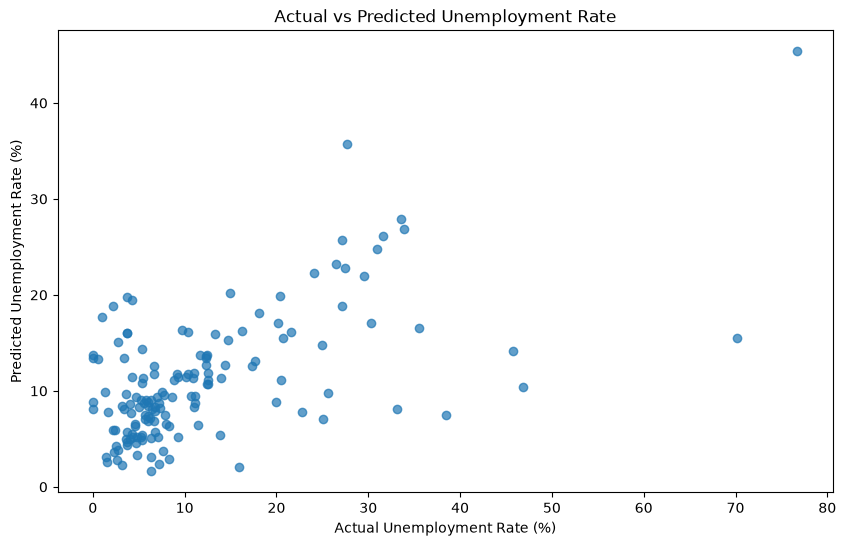

In [9]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.xlabel("Actual Unemployment Rate (%)")
plt.ylabel("Predicted Unemployment Rate (%)")

plt.title(
    "Actual vs Predicted Unemployment Rate"
)

plt.show()

In [10]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

print(feature_importance)

                                   Feature  Importance
0                       Estimated Employed    0.637126
1  Estimated Labour Participation Rate (%)    0.362874


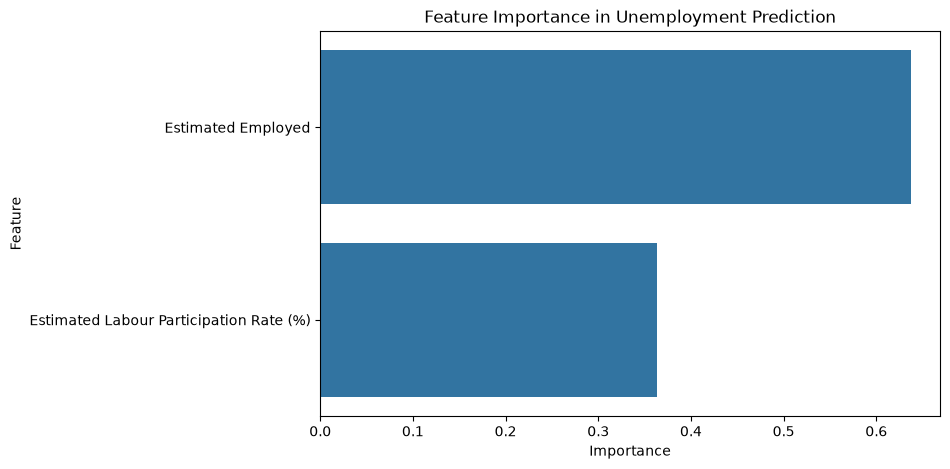

In [12]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance in Unemployment Prediction")

plt.show()

In [13]:
average_unemployment = (
    df["Estimated Unemployment Rate (%)"]
    .mean()
)

print(
    "Average Unemployment Rate:",
    round(average_unemployment, 2),
    "%"
)

Average Unemployment Rate: 11.79 %


In [14]:
# Convert date column
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True
)

# Create COVID period
df["Period"] = np.where(
    df["Date"] < "2020-03-01",
    "Pre-COVID",
    "COVID Period"
)

covid_analysis = (
    df.groupby("Period")
    ["Estimated Unemployment Rate (%)"]
    .mean()
)

print(covid_analysis)

Period
COVID Period    17.774363
Pre-COVID        9.509534
Name: Estimated Unemployment Rate (%), dtype: float64


In [15]:
pre_covid_rate = covid_analysis["Pre-COVID"]

covid_rate = covid_analysis["COVID Period"]

increase = covid_rate - pre_covid_rate

percentage_increase = (
    increase / pre_covid_rate
) * 100

print("\nEconomic Interpretation")
print("----------------------")

print(
    "Pre-COVID Unemployment Rate:",
    round(pre_covid_rate, 2),
    "%"
)

print(
    "COVID Period Unemployment Rate:",
    round(covid_rate, 2),
    "%"
)

print(
    "Increase in Unemployment:",
    round(increase, 2),
    "percentage points"
)

print(
    "Percentage Increase:",
    round(percentage_increase, 2),
    "%"
)


Economic Interpretation
----------------------
Pre-COVID Unemployment Rate: 9.51 %
COVID Period Unemployment Rate: 17.77 %
Increase in Unemployment: 8.26 percentage points
Percentage Increase: 86.91 %
